# Clasificación: Detección de Fatiga Muscular en Ciclismo 

## Análisis Preliminar del Problema

Carga del dataset

In [28]:
from datasets import load_dataset
import numpy as np
import pandas as pd

ds = load_dataset("YominE/Muscle_Fatigue_Cycling")
df = ds["train"].to_pandas()

fs = 1000
window_size = fs # 1 segundo = 1000 muestras

channels = ['Right Rectus femoris', 'Left Gluteus maximus',
       'Left Gastrocnemius medialis', 'Left Semitendinosus',
       'Left Biceps femoris caput longus', 'Right Vastus medialis',
       'Right Tibialis anterior', 'Left Gastrocnemius lateralis']

# Calcular cuántas ventanas completas caben
n_windows = len(df) // window_size

df = df.replace(2 , 1)

print(df.head())
print(f"Total de muestras: {len(df)}")
print(f"Ventanas de 1 segundo: {n_windows}")

    Time  Right Rectus femoris  Left Gluteus maximus  \
0  0.000             -0.000264             -0.000015   
1  0.001             -0.001002             -0.000045   
2  0.002             -0.002173             -0.000034   
3  0.003             -0.002676              0.000185   
4  0.004             -0.000844              0.000785   

   Left Gastrocnemius medialis  Left Semitendinosus  \
0                     0.000344             0.000108   
1                     0.001342             0.000429   
2                     0.002944             0.001133   
3                     0.003504             0.002319   
4                     0.000426             0.003950   

   Left Biceps femoris caput longus  Right Vastus medialis  \
0                          0.000182               0.000401   
1                          0.000712               0.002234   
2                          0.001692               0.007634   
3                          0.002820               0.017656   
4                     

Observando la cabecera del DataFrame, se puede apreciar que contiene 10 columnas. Ocho de ellas corresponden a las mediciones de las señales EMG provenientes de ocho músculos del pie dominante de la persona que realiza la prueba de ciclismo. Estas ocho columnas son variables numéricas continuas.
Por otro lado, se encuentra la columna de tiempo, la cual también corresponde a una variable numérica continua.
Finalmente, está la columna target, que, según la descripción del dataset, presenta un carácter ordinal, ya que refleja una progresión en el nivel de fatiga: 0 indica ausencia de fatiga, 1 representa una transición hacia la fatiga y 2 corresponde a un estado de fatiga. Pero, después del preprocesamiento se convierte en una variable categórica binaria, donde 0 representa la condición normal y 1 el desgaste muscular.

In [29]:
from scipy.signal import welch

def extraer_caracteristicas(ventana, fs=1000):
    """Extrae características de tiempo y frecuencia de una ventana 1D."""
    # --- Dominio del tiempo ---
    rms     = np.sqrt(np.mean(ventana**2)) # La energía o fuerza promedio de la señal
    varianza = np.var(ventana) # Qué tan dispersos están los valores
    zcr     = np.sum(np.diff(np.sign(ventana)) != 0) # Cuántas veces la señal cruza el cero
    mav     = np.mean(np.abs(ventana)) # Promedio del valor absoluto

    # --- Dominio de la frecuencia ---
    freqs, psd = welch(ventana, fs=fs) 
    pot_acum   = np.cumsum(psd) 
    idx_median = np.searchsorted(pot_acum, pot_acum[-1] / 2)
    frec_mediana = freqs[idx_median] # La frecuencia que divide la potencia espectral en dos mitades iguales

    pot_total  = np.sum(psd) # Energía total de la señal en frecuencia

    frec_media = np.sum(freqs * psd) / np.sum(psd) # Promedio ponderado de las frecuencias	

    return [rms, varianza, zcr, mav, pot_total, frec_media, frec_mediana]

# Construir el nuevo dataset
filas = []

for i in range(n_windows):
    inicio = i * window_size
    fin = inicio + window_size

    ventana_df = df.iloc[inicio:fin] # Todas las filas que estan entre el inicio y el final

    fila = {}

    for canal in channels:
        ventana = ventana_df[canal].values
        feats   = extraer_caracteristicas(ventana, fs=fs)

        nombres = ['rms', 'var', 'zcr', 'mav', 'pot', 'f_media', 'f_mediana']
        for nombre, valor in zip(nombres, feats):
            fila[f'{canal}_{nombre}'] = valor

    # El target de la ventana es el más frecuente en esas 1000 muestras
    fila['target'] = ventana_df['Target'].mode()[0]

    filas.append(fila)

nuevo_df = pd.DataFrame(filas)


Documente y justifique cada característica seleccionada en términos de su relevancia.

## Paso 3: EDA

In [43]:
import matplotlib.pyplot as plt
lista_de_features = nuevo_df.columns.to_list()

# Obetener cada musculo con sus 8 caracteristicas
primer_musculo = lista_de_features[0:7]
segundo_musculo = lista_de_features[7:14]
tercer_musculo = lista_de_features[14:21]
cuarto_musculo = lista_de_features[21:28]
quinto_musculo = lista_de_features[28:35]
sexto_musculo = lista_de_features[35:42]
septimo_musculo = lista_de_features[42:49]
octavo_musculo = lista_de_features[49:56]


### Distribuciones de variables y estadísticos descriptivos

La estadistica descriptiva de la caracteristica Right Rectus femoris_rms


count    3002.000000
mean        0.035700
std         0.024379
min         0.002970
25%         0.021569
50%         0.029745
75%         0.042171
max         0.190683
Name: Right Rectus femoris_rms, dtype: float64

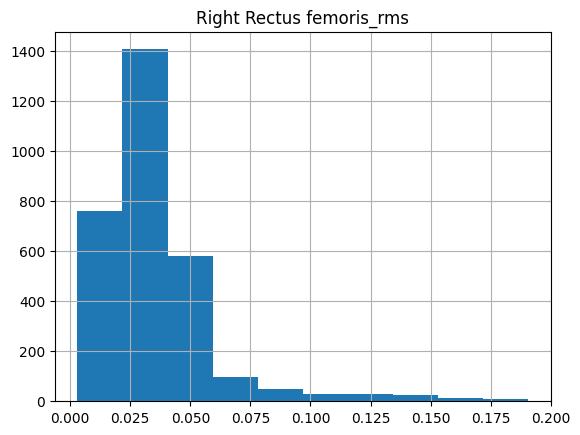

La estadistica descriptiva de la caracteristica Right Rectus femoris_var


count    3002.000000
mean        0.001869
std         0.003613
min         0.000009
25%         0.000465
50%         0.000885
75%         0.001778
max         0.036360
Name: Right Rectus femoris_var, dtype: float64

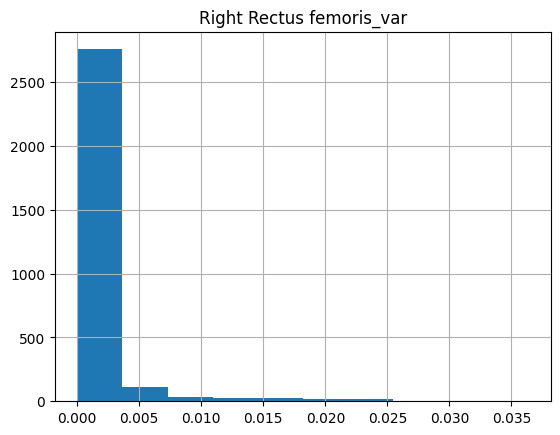

La estadistica descriptiva de la caracteristica Right Rectus femoris_zcr


count    3002.000000
mean      108.874084
std        13.094489
min        63.000000
25%       100.000000
50%       109.000000
75%       118.000000
max       155.000000
Name: Right Rectus femoris_zcr, dtype: float64

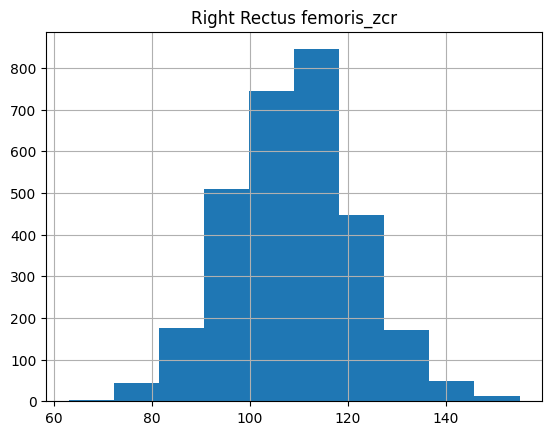

La estadistica descriptiva de la caracteristica Right Rectus femoris_mav


count    3002.000000
mean        0.022596
std         0.015262
min         0.002243
25%         0.013461
50%         0.018516
75%         0.026945
max         0.128436
Name: Right Rectus femoris_mav, dtype: float64

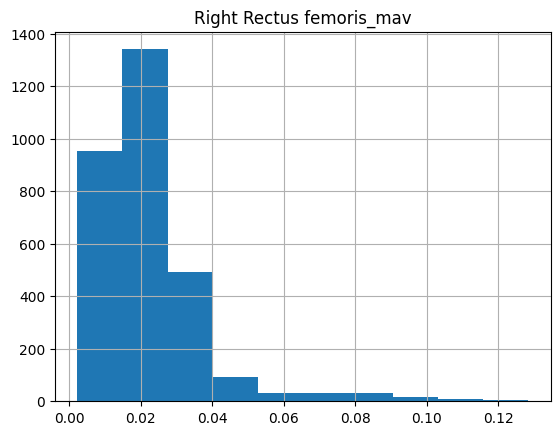

La estadistica descriptiva de la caracteristica Right Rectus femoris_pot


count    3002.000000
mean        0.000483
std         0.000982
min         0.000002
25%         0.000099
50%         0.000223
75%         0.000444
max         0.011503
Name: Right Rectus femoris_pot, dtype: float64

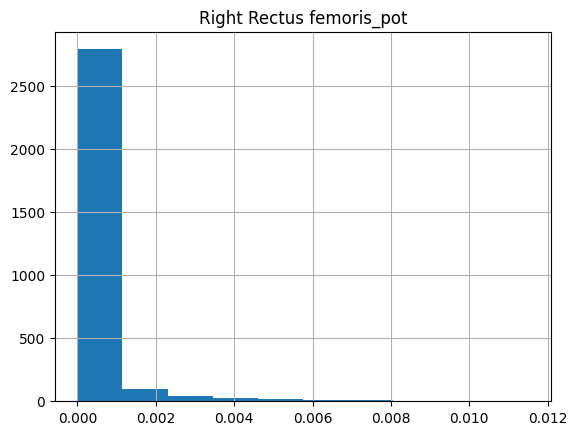

La estadistica descriptiva de la caracteristica Right Rectus femoris_f_media


count    3002.000000
mean       54.015741
std         6.264138
min        20.487091
25%        50.660326
50%        54.555808
75%        58.067109
max        71.694239
Name: Right Rectus femoris_f_media, dtype: float64

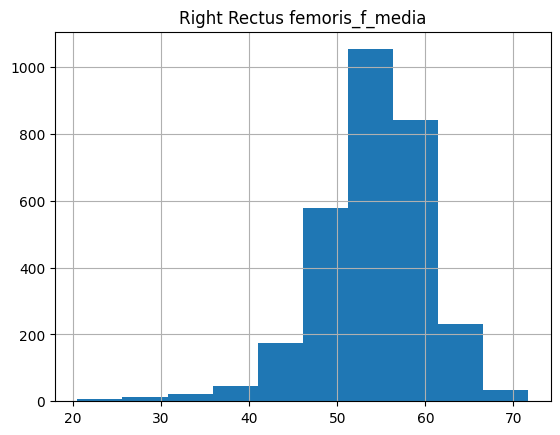

La estadistica descriptiva de la caracteristica Right Rectus femoris_f_mediana


count    3002.000000
mean       47.493078
std         8.368634
min        15.625000
25%        42.968750
50%        46.875000
75%        50.781250
max        74.218750
Name: Right Rectus femoris_f_mediana, dtype: float64

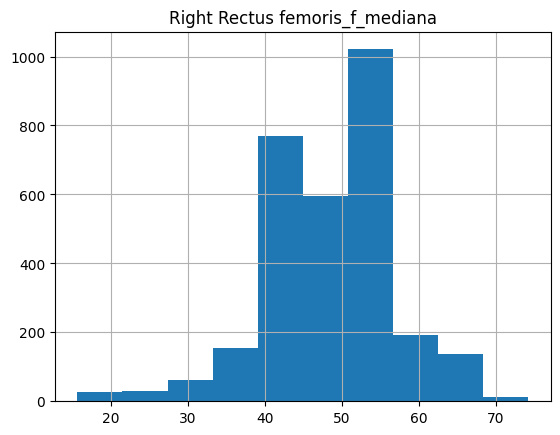

In [44]:
for caracteristica in primer_musculo:
    print(f"La estadistica descriptiva de la caracteristica {caracteristica}")
    display(nuevo_df[caracteristica].describe())

    nuevo_df.hist(column=caracteristica)
    plt.show()

#### Right Rectus femoris_rms
La característica Right Rectus femoris_rms presenta una distribución no normal, con asimetría positiva. La mayoría de las observaciones se concentran en valores bajos, mientras que unos pocos registros alcanzan valores considerablemente más altos, generando una cola hacia la derecha. La diferencia entre la media y la mediana sugiere la presencia de valores extremos o poco frecuentes.

#### Right Rectus femoris_var
La característica Right Rectus femoris_var presenta una distribución fuertemente asimétrica postiva. La gran mayoría de las observaciones se concentra en valores muy cercanos a cero, mientras que un grupo reducido de registros alcanza valores considerablemente superiores, generando una cola larga hacia la derecha. Esto se refleja en la diferencia entre la mediana (0.000885) y la media (0.001869), así como en la distancia entre el tercer cuartil (0.001778) y el valor máximo (0.036360), lo que sugiere la presencia de valores extremos o poco frecuentes. Dado que esta variable representa la varianza de la señal EMG, dichos valores altos podrían estar asociados a segmentos con mayor dispersión o variabilidad en la actividad muscular. Por ello, resulta pertinente analizar su relación con la variable objetivo para determinar si estos incrementos en la variabilidad se presentan con mayor frecuencia en la clase correspondiente a fatiga.

#### Right Rectus femoris_zcr
La característica Right Rectus femoris_zcr presenta una distribución mucho más cercana a una forma simétrica y aproximadamente normal. La mayoría de las observaciones se concentra alrededor de los valores centrales, con una media de 108.87 y una mediana de 109, lo cual sugiere poca asimetría. Además, el rango intercuartílico va de 100 a 118, indicando que el 50% central de los datos se encuentra relativamente concentrado en ese intervalo. Aunque existen valores mínimos (63) y máximos (155) más alejados, no se observa una cola tan marcada ni una presencia tan evidente de valores extremos como en las variables rms y var.

#### Right Rectus femoris_mav
La característica Right Rectus femoris_mav presenta una distribución no normal con asimetría positiva. La mayoría de las observaciones se concentra en valores bajos, principalmente entre aproximadamente 0.01 y 0.03, mientras que un número reducido de registros alcanza valores considerablemente más altos, generando una cola hacia la derecha. Esta tendencia también se refleja en la diferencia entre la media (0.022596) y la mediana (0.018516), lo que sugiere la presencia de valores altos poco frecuentes o potenciales outliers. Además, la distancia entre el tercer cuartil (0.026945) y el valor máximo (0.128436) refuerza esta idea.

#### Right Rectus femoris_pot
La característica Right Rectus femoris_pot presenta una distribución fuertemente asimétrica positiva. La gran mayoría de las observaciones se concentra en valores muy cercanos a cero, mientras que un número reducido de registros alcanza valores considerablemente más altos, lo que genera una cola larga hacia la derecha. Esta tendencia se refleja en la diferencia entre la media (0.000483) y la mediana (0.000223), así como en la amplia separación entre el tercer cuartil (0.000444) y el valor máximo (0.011503), lo cual sugiere la presencia de valores extremos o poco frecuentes.

#### Right Rectus femoris_f_media
La característica Right Rectus femoris_f_media presenta una distribución aproximadamente normal y relativamente concentrada alrededor de los valores centrales, principalmente entre 50 y 60. La cercanía entre la media (54.015741) y la mediana (54.555808) sugiere que no existe un sesgo pronunciado; sin embargo, el hecho de que la media sea ligeramente menor que la mediana, junto con la presencia de valores mínimos alejados (20.487091), indica una leve asimetría hacia la izquierda. Además, el rango intercuartílico, comprendido entre 50.660326 y 58.067109, muestra que el 50% central de las observaciones se encuentra relativamente concentrado, lo que sugiere una dispersión moderada.

#### Right Rectus femoris_f_mediana
La característica Right Rectus femoris_f_mediana presenta una distribución aproximadamente normal y relativamente concentrada en torno a valores intermedios, principalmente entre 40 y 55. La media (47.493078) y la mediana (46.875000) son cercanas, lo que sugiere que no existe un sesgo muy pronunciado. Sin embargo, el valor máximo (74.218750) es más lejano respecto al tercer cuartil (50.781250) que el mínimo (15.625000) respecto al primer cuartil (42.968750), lo que podría indicar una ligera asimetría positiva o, al menos, una mayor dispersión hacia valores altos. Además, el rango intercuartílico muestra que el 50% central de las observaciones se concentra entre 42.968750 y 50.781250, lo que refleja una dispersión moderada.

La estadistica descriptiva de la caracteristica Left Gluteus maximus_rms


count    3002.000000
mean        0.011715
std         0.017748
min         0.002799
25%         0.005364
50%         0.007019
75%         0.010890
max         0.196428
Name: Left Gluteus maximus_rms, dtype: float64

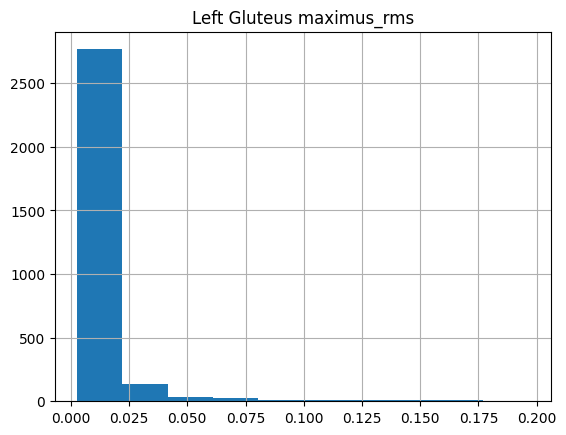

La estadistica descriptiva de la caracteristica Left Gluteus maximus_var


count    3002.000000
mean        0.000452
std         0.002460
min         0.000008
25%         0.000029
50%         0.000049
75%         0.000119
max         0.038583
Name: Left Gluteus maximus_var, dtype: float64

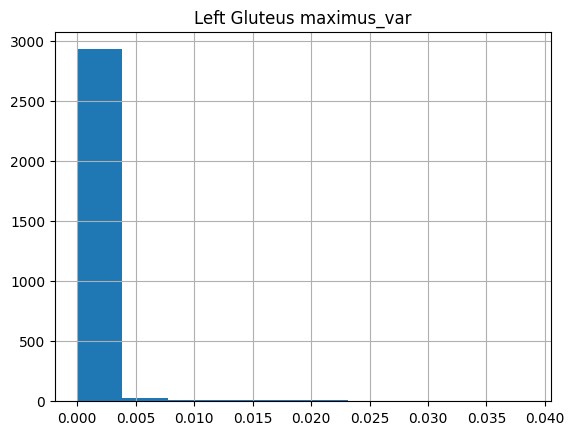

La estadistica descriptiva de la caracteristica Left Gluteus maximus_zcr


count    3002.000000
mean      120.347435
std        17.927588
min        45.000000
25%       110.000000
50%       122.000000
75%       133.000000
max       174.000000
Name: Left Gluteus maximus_zcr, dtype: float64

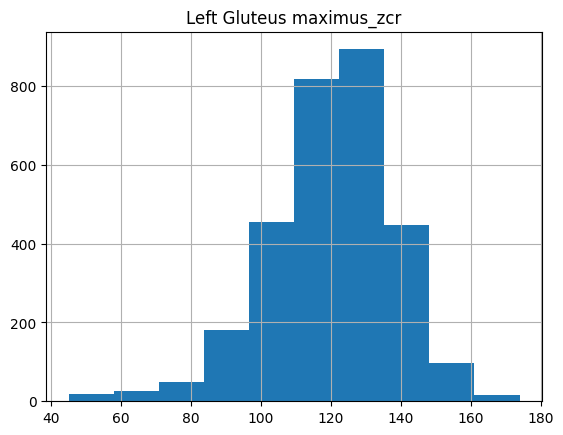

La estadistica descriptiva de la caracteristica Left Gluteus maximus_mav


count    3002.000000
mean        0.008064
std         0.012312
min         0.002164
25%         0.004019
50%         0.005004
75%         0.007427
max         0.148809
Name: Left Gluteus maximus_mav, dtype: float64

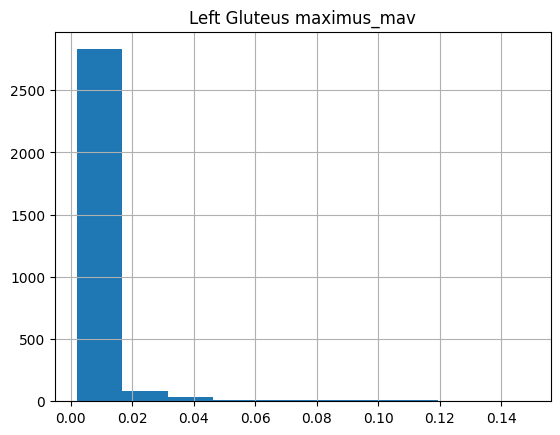

La estadistica descriptiva de la caracteristica Left Gluteus maximus_pot


count    3002.000000
mean        0.000116
std         0.000654
min         0.000002
25%         0.000007
50%         0.000012
75%         0.000029
max         0.012241
Name: Left Gluteus maximus_pot, dtype: float64

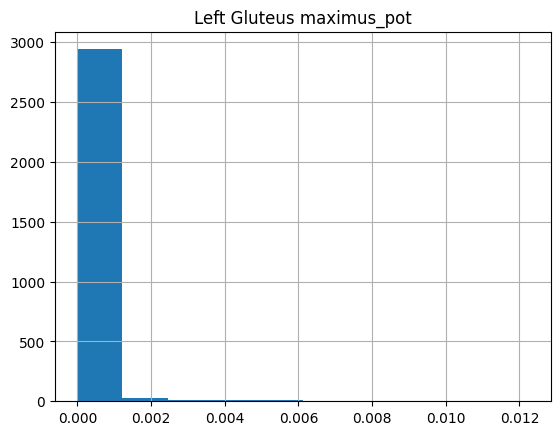

La estadistica descriptiva de la caracteristica Left Gluteus maximus_f_media


count    3002.000000
mean       48.687443
std         9.025091
min        15.859232
25%        42.555094
50%        48.578192
75%        54.641334
max        82.172354
Name: Left Gluteus maximus_f_media, dtype: float64

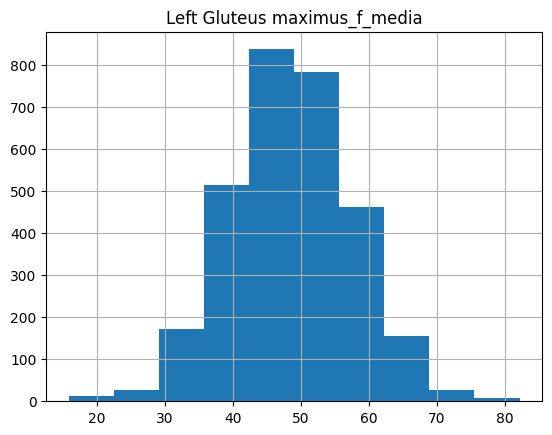

La estadistica descriptiva de la caracteristica Left Gluteus maximus_f_mediana


count    3002.000000
mean       39.560866
std         9.437805
min        11.718750
25%        35.156250
50%        39.062500
75%        42.968750
max        85.937500
Name: Left Gluteus maximus_f_mediana, dtype: float64

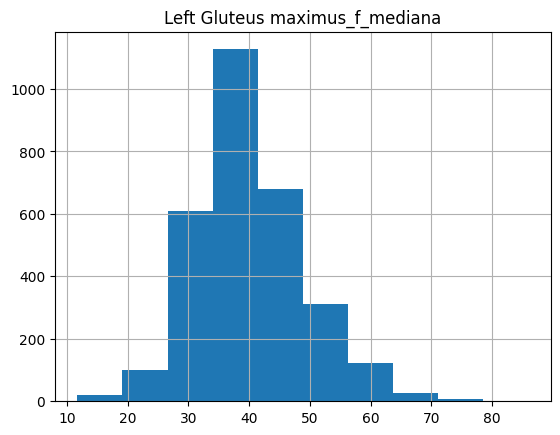

In [45]:
for caracteristica in segundo_musculo:
    print(f"La estadistica descriptiva de la caracteristica {caracteristica}")
    display(nuevo_df[caracteristica].describe())

    nuevo_df.hist(column=caracteristica)
    plt.show()

#### Left Gluteus maximus_rms
La característica Left Gluteus maximus_rms presenta una distribución fuertemente asimétrica postiva. La gran mayoría de las observaciones se concentra en valores muy bajos, principalmente por debajo de 0.02, mientras que un número reducido de registros alcanza valores considerablemente más altos, generando una cola larga hacia la derecha. Esta tendencia se refleja en la diferencia entre la media (0.011715) y la mediana (0.007019), así como en la amplia separación entre el tercer cuartil (0.010890) y el valor máximo (0.196428), lo que sugiere la presencia de valores extremos o eventos poco frecuentes.

#### Left Gluteus maximus_var
La característica Left Gluteus maximus_var presenta una fuerte asimétrica postiva. Prácticamente todas las observaciones se concentran en valores muy cercanos a cero, mientras que solo un número muy reducido de registros alcanza valores considerablemente mayores, generando una cola larga hacia la derecha. Esta tendencia se evidencia en la diferencia entre la media (0.000452) y la mediana (0.000049), así como en la gran distancia entre el tercer cuartil (0.000119) y el valor máximo (0.038583), lo que sugiere una presencia marcada de valores extremos o poco frecuentes.

#### Left Gluteus maximus_zcr
La característica Left Gluteus maximus_zcr presenta una distribución aproximadamente normal, con una concentración principal de observaciones entre 110 y 133 cruces por cero. La cercanía entre la media (120.347435) y la mediana (122) sugiere ausencia de un sesgo fuerte, aunque el hecho de que la media sea ligeramente menor que la mediana podría indicar una leve asimetría negativa. Además, el rango intercuartílico, comprendido entre 110 y 133, muestra que el 50% central de los datos se encuentra relativamente concentrado en ese intervalo, lo que sugiere una dispersión moderada. Aunque existen valores mínimos (45) y máximos (174) alejados del centro, no se observa una cola tan marcada ni una presencia tan evidente de valores extremos como en variables como rms, var o pot.

#### Left Gluteus maximus_mav
La característica Left Gluteus maximus_mav presenta una distribución no normal con un marcado sesgo hacia la derecha. La gran mayoría de las observaciones se concentra en valores bajos, principalmente por debajo de 0.02, mientras que solo un número reducido de registros alcanza valores considerablemente más altos, generando una cola larga hacia la derecha. Esta tendencia se refleja en la diferencia entre la media (0.008064) y la mediana (0.005004), así como en la amplia separación entre el tercer cuartil (0.007427) y el valor máximo (0.148809), lo que sugiere la presencia de valores extremos o eventos poco frecuentes.


In [ ]:
for caracteristica in tercer_musculo:
    print(f"La estadistica descriptiva de la caracteristica {caracteristica}")
    display(nuevo_df[caracteristica].describe())

    nuevo_df.hist(column=caracteristica)
    plt.show()

### Matriz de correlaciones

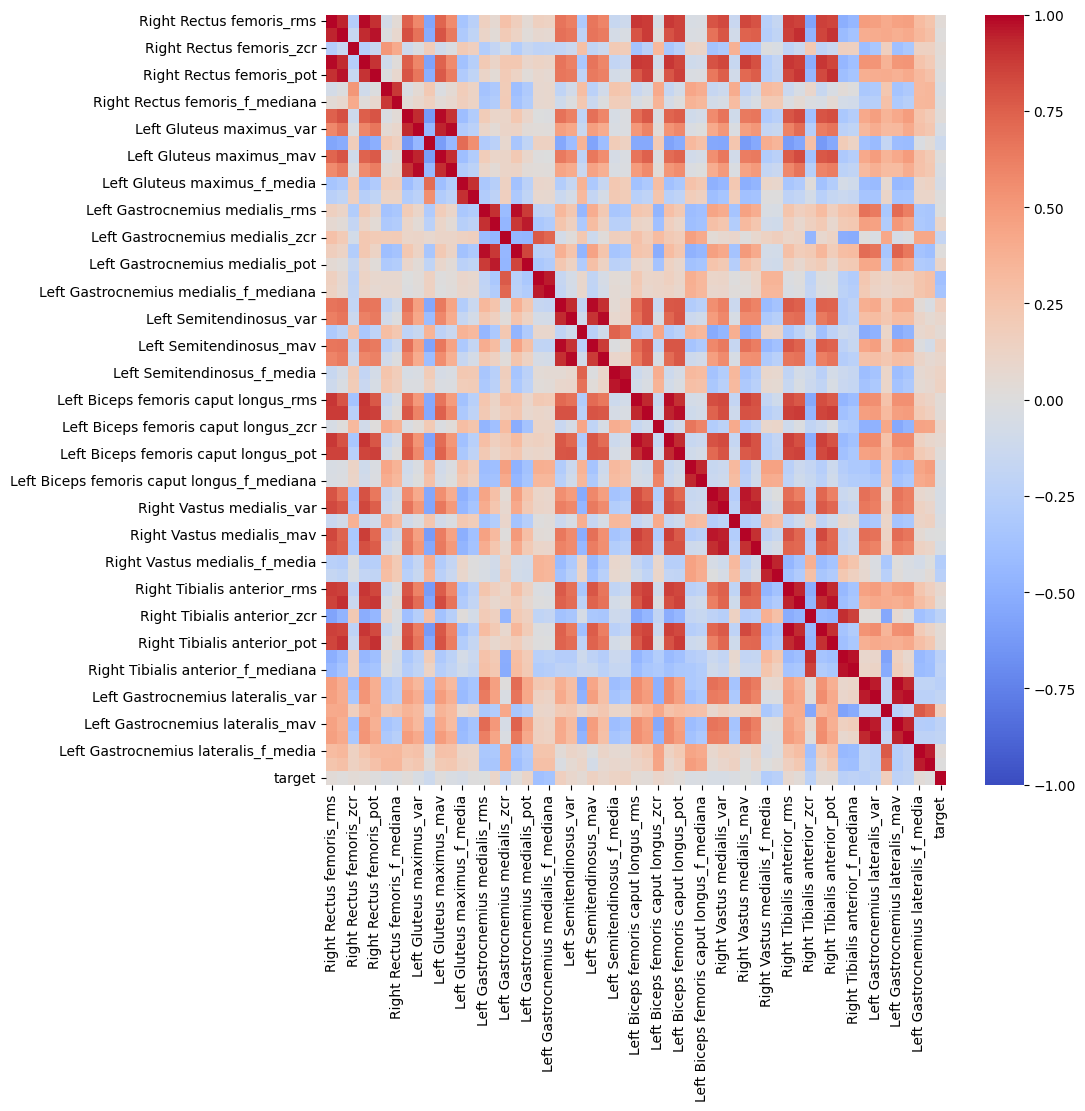

In [66]:
import seaborn as sns
corr = nuevo_df.corr(method='pearson')
plt.figure(figsize=(10 , 10))
sns.heatmap(
    corr,
    cmap='coolwarm',
    vmin=-1, vmax=1,
    center=0,
)
plt.show()

Ya que, como la matriz de correlaciones es simetrica, podemos observarla con unicamente ver la parte triangular superior o inferior sin la diagonal. En este caso vamos a ver la parte triangular superior

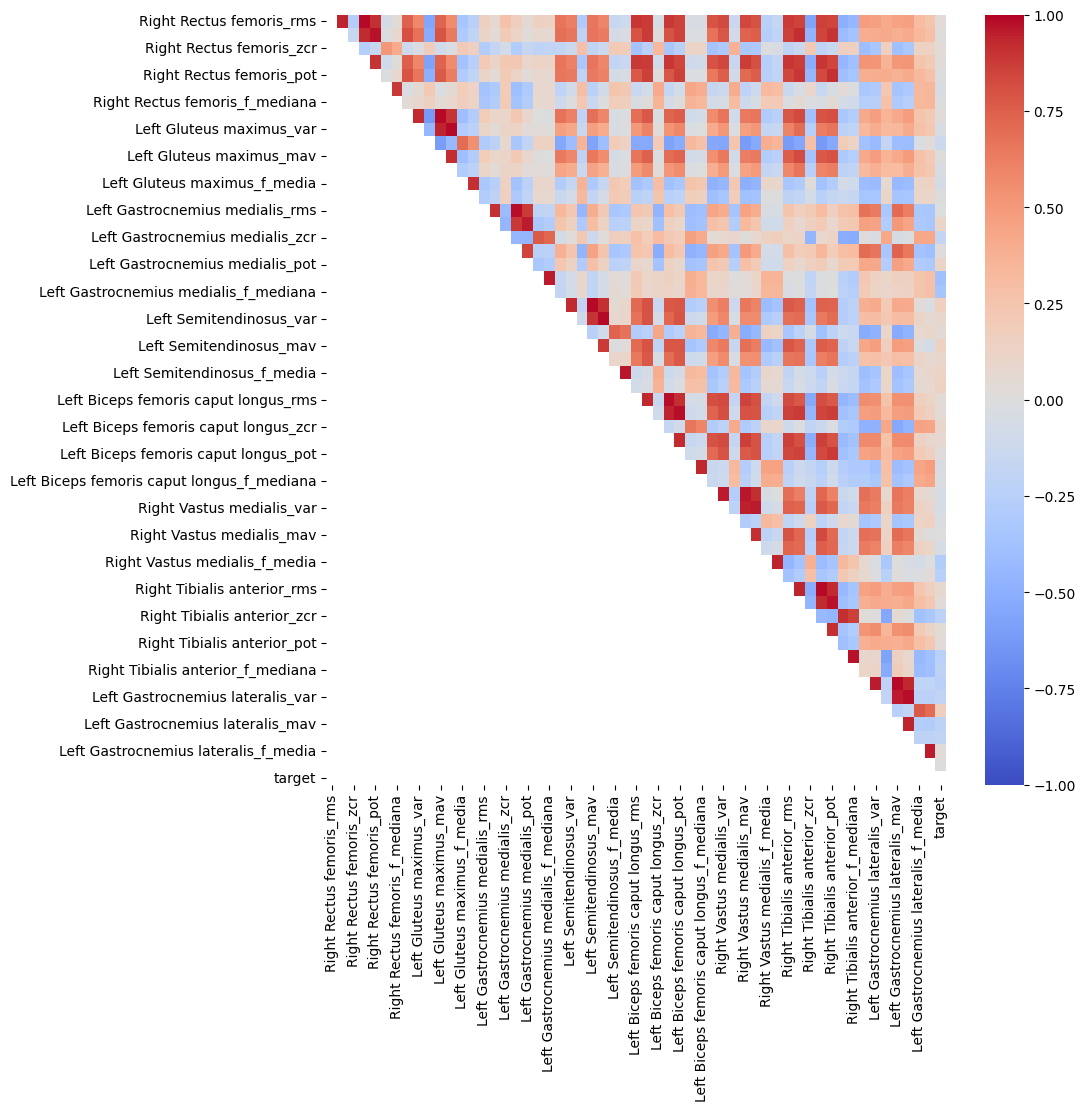

In [65]:
tri_superior = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)) # Triangular superior sin diagonal
plt.figure(figsize=(10 , 10))
sns.heatmap(
    tri_superior,
    cmap='coolwarm',
    vmin=-1, vmax=1,
    center=0,
)
plt.show()

In [ ]:
top_20 = (
    tri_superior
    .stack()
    .reset_index()
)

top_20.columns = ['variable_1', 'variable_2', 'correlacion']
top_20['abs_corr'] = top_20['correlacion'].abs() # Util para ordenar. Una correlacion negativa tambien puede ser muy fuerte

top_20 = top_20.sort_values('abs_corr', ascending=False).head(20)

print(top_20)

                                variable_1  \
409               Left Gluteus maximus_rms   
1221               Left Semitendinosus_rms   
467               Left Gluteus maximus_var   
3                 Right Rectus femoris_rms   
2845      Left Gastrocnemius lateralis_rms   
2439           Right Tibialis anterior_rms   
1279               Left Semitendinosus_var   
1627  Left Biceps femoris caput longus_rms   
815        Left Gastrocnemius medialis_rms   
2903      Left Gastrocnemius lateralis_var   
1685  Left Biceps femoris caput longus_var   
61                Right Rectus femoris_var   
2727       Right Tibialis anterior_f_media   
2497           Right Tibialis anterior_var   
2033             Right Vastus medialis_rms   
1509           Left Semitendinosus_f_media   
1103   Left Gastrocnemius medialis_f_media   
2031             Right Vastus medialis_rms   
2902      Left Gastrocnemius lateralis_var   
873        Left Gastrocnemius medialis_var   

                                 

### Relación entre características-target y análisis de balance de clases

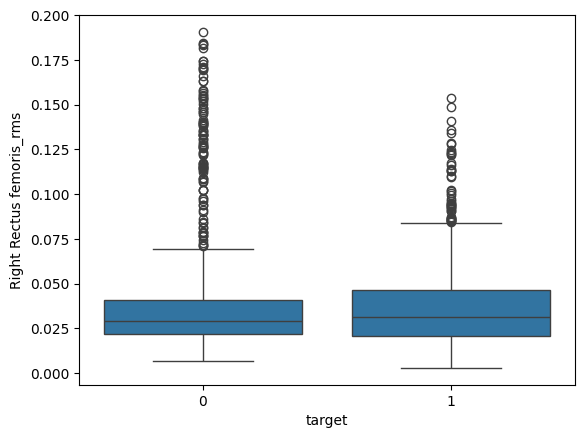

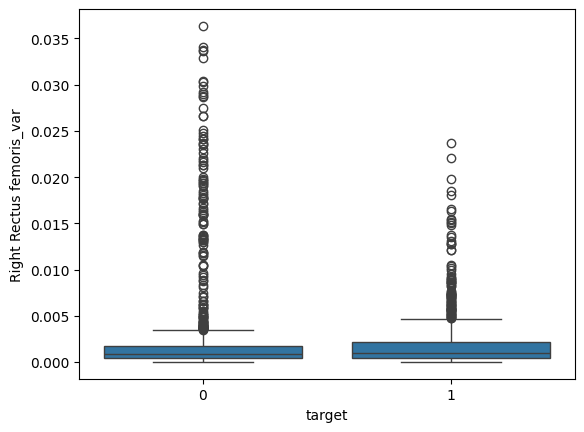

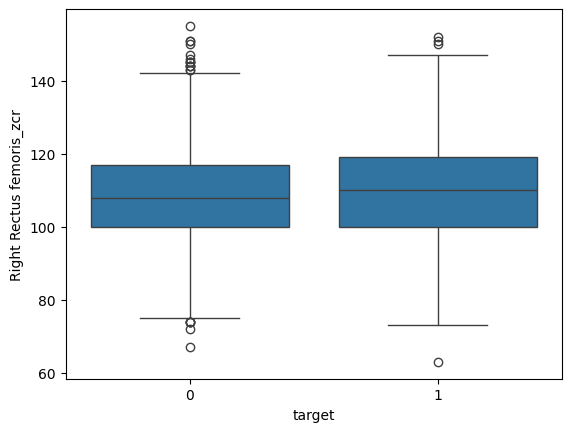

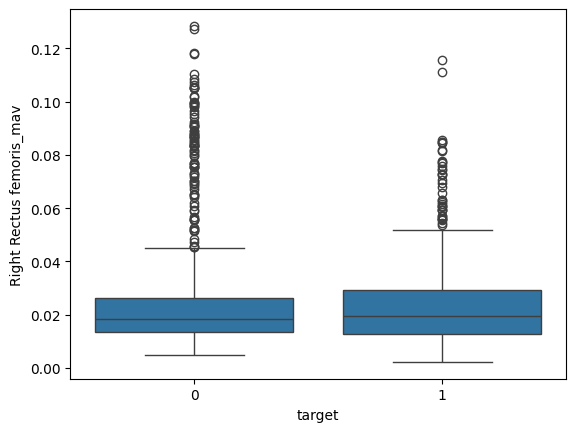

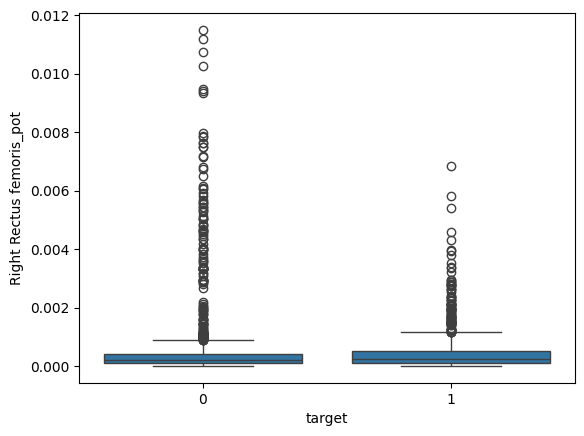

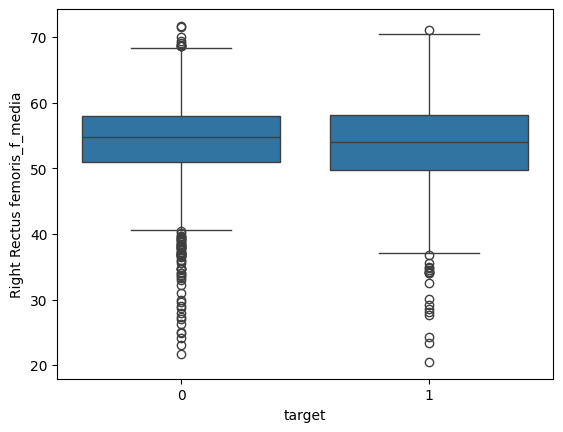

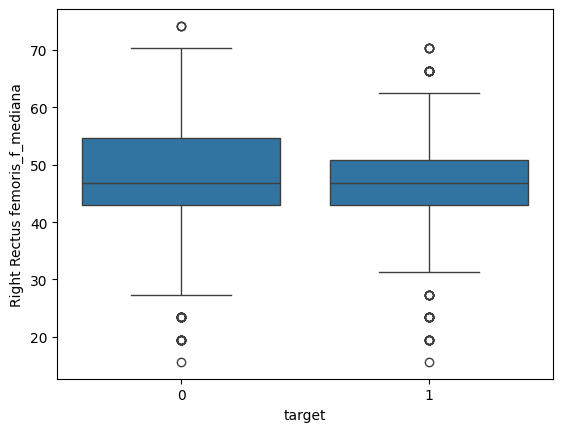

Proporciones de las clases


target
0    2128
1     874
Name: count, dtype: int64

target
0    70.886076
1    29.113924
Name: proportion, dtype: float64

In [80]:
for caracteristica in primer_musculo:
    sns.boxplot(x=nuevo_df['target'], y=nuevo_df[caracteristica])
    plt.show()

print("Proporciones de las clases")
display(nuevo_df['target'].value_counts())
display(nuevo_df['target'].value_counts(normalize=True) * 100)

### Señales en el tiempo

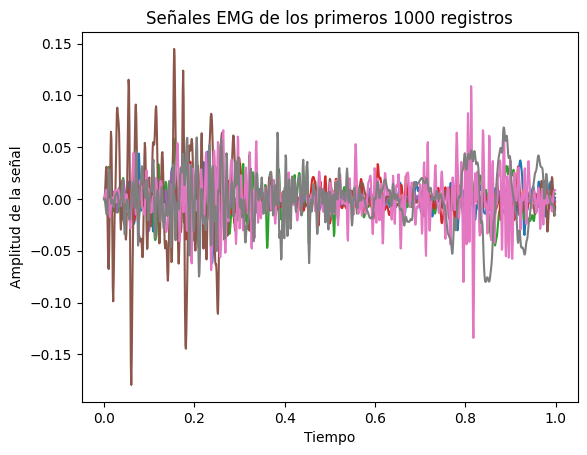

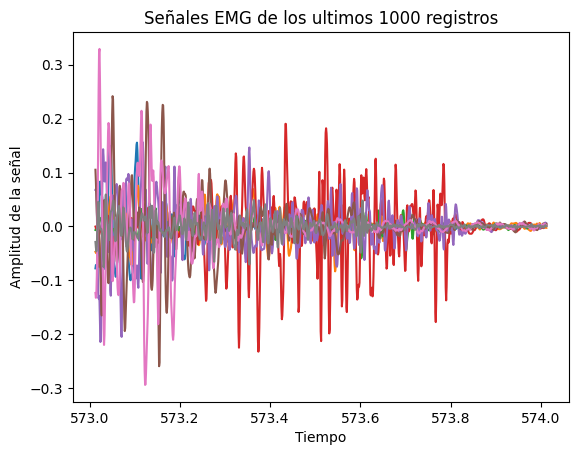

In [97]:
for channel in channels:
    sns.lineplot(data=df.head(1000) , x='Time' , y=channel)
plt.title('Señales EMG de los primeros 1000 registros')
plt.xlabel('Tiempo')
plt.ylabel('Amplitud de la señal')
plt.show()

for channel in channels:
    sns.lineplot(data=df.tail(1000) , x='Time' , y=channel)
plt.title('Señales EMG de los ultimos 1000 registros')
plt.xlabel('Tiempo')
plt.ylabel('Amplitud de la señal')
plt.show()

### Paso 4: Procesamiento de Datos

In [99]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# 1. Separar variables predictoras y target
X = nuevo_df.drop(columns='target')
y = nuevo_df['target']

# 2. División 70/15/15
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

# 3. Pipeline de preprocesamiento
pipeline_preprocesamiento = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# 4. Ajustar solo con train
X_train_proc = pipeline_preprocesamiento.fit_transform(X_train)
X_val_proc = pipeline_preprocesamiento.transform(X_val)
X_test_proc = pipeline_preprocesamiento.transform(X_test)

# 5. Verificación
print("Shapes:")
print("X_train:", X_train_proc.shape)
print("X_val:", X_val_proc.shape)
print("X_test:", X_test_proc.shape)

print("\nDistribución de clases:")
print("Train:")
print(y_train.value_counts(normalize=True))
print("\nVal:")
print(y_val.value_counts(normalize=True))
print("\nTest:")
print(y_test.value_counts(normalize=True))

Shapes:
X_train: (2101, 56)
X_val: (450, 56)
X_test: (451, 56)

Distribución de clases:
Train:
target
0    0.70871
1    0.29129
Name: proportion, dtype: float64

Val:
target
0    0.708889
1    0.291111
Name: proportion, dtype: float64

Test:
target
0    0.709534
1    0.290466
Name: proportion, dtype: float64
